# AI-driven ChemE car Competition

## Manual tunning and control


为了更加可靠的识别颜色，这里使用了HSV颜色代码，HSV的数值代表以下意思：H (Hue): 0–360 degrees；S (Saturation): 0–100 (percent)；V (Value): 0–100 (percent)。

可以使用以下链接挑选颜色：

颜色挑选：https://colorpicker.me/#e5fe1d

上传图片挑选颜色：https://redketchup.io/color-picker

HSV lower color里面的每一项数值需要对应小于HSV upper color，比如hsv_lower = [200, 0 ,0], hsv_upper = [200, 100 ,100]。但从定义上将S和V的数值大意味着更鲜艳更亮的颜色，所以在碘钟反应中选择的浅黄应该对应hsv_upper，深黄对应比如hsv_lower。

Color change threshold指所指定区域内有多少比例的像素处于设定的颜色范围内

In [ ]:
from camera_control import CameraControl
from MKSMotor_USB import MKSMotor, MotorControlUI
import time
import ipywidgets as widgets
from IPython.display import display
import cv2
import threading

# CameraControl
cam_control = CameraControl(digit_cam_id=1, color_cam_id=0)
cam_control.display_UI()

# Configure serial port parameters, Linux/MacOS starts with dev/tty., Windows uses "COM3, COM5" etc.
port="COM3"
motor = MKSMotor(port=port)  # Motor initialization
motor_ui = MotorControlUI(motor)
motor_ui.display_controls()


Output()

## Ready to go competition
### Step 1: Configure your MNIST algorithm
请先加载你的MNIST模型，请使用作业中的格式，以便加载

In [3]:
# put your trained homework here!
# 请加载自己的模型
from nn import NeuralNetwork
mnist_model = NeuralNetwork.load_model("mnist_trained_model.pkl")

# from nn2 import NeuralNetwork
# mnist_model = NeuralNetwork.load_model("trained_model.pkl")

Model loaded from mnist_trained_model.pkl


Test your model before going forward!

在这里先测试一下你的模型，以确保模型正常工作。

Model loaded from mnist_trained_model.pkl
Your model correctly predicted the '0' digit.


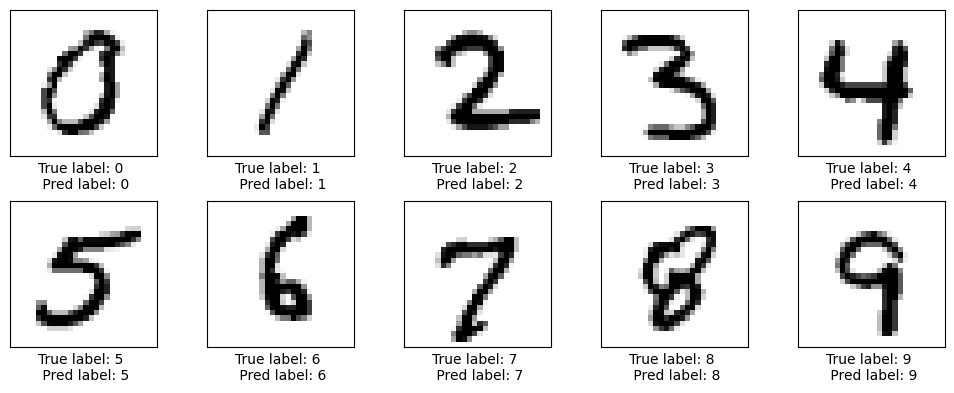

In [4]:
from mnist_model_test import random_read_mnist_csv, MNIST_nn_dummy, plot_images

csv_file = "mnist_sample.csv"  
selected_images, selected_labels = random_read_mnist_csv(csv_file)
# ------------ 在这里替换你的模型 --------------- #
# mnist_model = MNIST_nn_dummy()
mnist_model = NeuralNetwork.load_model("mnist_trained_model.pkl")
# ------------ 在这里替换你的模型 --------------- #
pred_labels = []
for img in selected_images:
    pred_labels.append(mnist_model.predict(img))

if pred_labels[0] == 0:
    print("Your model correctly predicted the '0' digit.")
else:
    print("Your model failed to predict.")
    
plot_images(selected_images, selected_labels, pred_labels)

### Step 2: Run for target digit

In [5]:
from contest_helper_code import preflight_check, DigitContestRunner

preflight_check(cam_control, motor, mnist_model=globals().get("mnist_model"), step=2)
runner1 = DigitContestRunner(motor, cam_control, motor_ui, mnist_model)
runner1.display()

### Step 3: Configure your chemistry timing algorithm

In [22]:
# from xxx import composition_pred

# -------------------------------------------------------------- #
# 把你训练好的预测函数放在这里，必须是使用预测函数，如果直接手填不合格 #
def composition_pred(target_time):
    offset = 0
    # return (target_time+2.9103+offset )/0.1292
    return (target_time + 1.3566 + offset )/0.1076
# -------------------------------------------------------------- #
target_time = 52.54 # s
print(f'The desired composition of solution should be {composition_pred(target_time)} uL.')

The desired composition of solution should be 500.8977695167286 uL.


### Step 4: Run for target timing

In [7]:
from contest_helper_code import preflight_check, ColorContestRunner

preflight_check(cam_control, motor, step=4)
runner2 = ColorContestRunner(motor, cam_control, motor_ui)
runner2.display()

### Step 5: Results calculation

In [21]:
if runner1.stop_pos is None or runner2.stop_pos is None:
    print("You must run each step sequentially before calculating your contest results!")
else:
    diff = abs(runner2.stop_pos - runner1.stop_pos)
    print(f"Step 2 stop position : {runner1.stop_pos:.2f} mm  (elapsed {runner1.stop_elapsed:.2f} s)")
    print(f"Step 4 stop position : {runner2.stop_pos:.2f} mm  (elapsed {runner2.stop_elapsed:.2f} s)")
    print(f"Difference between two runs: {diff:.2f} mm")

Step 2 stop position : 175.62 mm  (elapsed 52.34 s)
Step 4 stop position : 162.93 mm  (elapsed 48.56 s)
Difference between two runs: 12.69 mm
